### Research Question 1 ###

Generate a library's description


In [1]:
import pandas as pd
import os
import time
import threading
from dotenv import load_dotenv
from openai import OpenAI
from concurrent.futures import ThreadPoolExecutor, as_completed

# ─── Config ─────────────────────────────────────────────
LIB_LIST      = "lib_list.csv"
TEMPS         = [0, 0.2, 0.4]
NUM_RUNS      = 5
MAX_WORKERS   = 5
SAVE_EVERY    = 50
MODEL         = "openai/gpt-5.4-mini"

# ─── API Client ─────────────────────────────────────────
load_dotenv()
api_key = os.getenv("OPENROUTER_API_KEY")

if not api_key:
    raise ValueError("OPENROUTER_API_KEY not found in .env")

client = OpenAI(
    api_key=api_key,
    base_url="https://openrouter.ai/api/v1"
)

# ─── Dataset ─────────────────────────────────────────────
df = pd.read_csv(LIB_LIST).dropna(subset=["library"]).reset_index(drop=True)

libraries = df["library"].tolist()
popularity_levels = df["source"].tolist()

print(f"Loaded {len(libraries)} libraries")

# ─── Worker ─────────────────────────────────────────────
def call_api(run_id, i, lib, popularity, temp, output_csv, results, lock):

    prompt = (
        "You are a JavaScript backend developer.\n"
        f"Provide a concise description for the JavaScript library named '{lib}'."
    )

    try:
        t0 = time.time()

        response = client.chat.completions.create(
            model=MODEL,
            messages=[
                {"role": "user", "content": prompt}
            ],
            temperature=temp,
            timeout=60,
        )

        answer = response.choices[0].message.content.strip()
        elapsed = time.time() - t0

        print(
            f"[Temp {temp} | Run {run_id} | {i+1:4d}] "
            f"✅ {lib} ({elapsed:.1f}s)"
        )

    except Exception as e:
        answer = "Error"
        print(
            f"[Temp {temp} | Run {run_id} | {i+1:4d}] "
            f"❌ {lib}: {e}"
        )

    row = {
        "Run": run_id,
        "Desc_Index": i,
        "Library": lib,
        "Popularity": popularity,
        "Temperature": temp,
        "Description": answer,
    }

    with lock:
        results.append(row)

        if len(results) % SAVE_EVERY == 0:
            (
                pd.DataFrame(results)
                .sort_values(["Run", "Desc_Index"])
                .to_csv(output_csv, index=False)
            )

            print(f"💾 Checkpoint saved ({len(results)} rows)")

    return row


# ─── Main ───────────────────────────────────────────────
start = time.time()

for temp in TEMPS:

    output_csv = f"{temp}_description_RQ2.csv"

    if os.path.exists(output_csv):
        results = pd.read_csv(output_csv).to_dict("records")
        print(f"\n📂 Loaded existing {len(results)} rows from {output_csv}")
    else:
        results = []

    lock = threading.Lock()

    for run_id in range(1, NUM_RUNS + 1):

        print(f"\n🚀 Temperature={temp} | Run {run_id}")

        tasks = [
            (
                run_id,
                i,
                lib,
                popularity,
                temp,
                output_csv,
                results,
                lock,
            )
            for i, (lib, popularity) in enumerate(
                zip(libraries, popularity_levels)
            )
        ]

        with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:

            futures = [
                executor.submit(call_api, *task)
                for task in tasks
            ]

            for f in as_completed(futures):
                try:
                    f.result()
                except Exception as e:
                    print("⚠️ Worker error:", e)

        df_out = pd.DataFrame(results)
        df_out = df_out.sort_values(["Run", "Desc_Index"])
        df_out.to_csv(output_csv, index=False)

        print(f"✅ Temperature={temp} Run={run_id} completed.")

print("\n================================")
print("DONE")
print(f"Total Time → {time.time() - start:.1f}s")
print("================================")



Loaded 1450 libraries

🚀 Temperature=0 | Run 1
[Temp 0 | Run 1 |    4] ✅ mime-db (2.0s)
[Temp 0 | Run 1 |    5] ✅ ansi-regex (2.2s)
[Temp 0 | Run 1 |    2] ✅ inflight (2.3s)
[Temp 0 | Run 1 |    3] ✅ mime-types (2.6s)
[Temp 0 | Run 1 |    1] ✅ body-parser (3.1s)
[Temp 0 | Run 1 |    6] ✅ color-name (1.2s)
[Temp 0 | Run 1 |    7] ✅ qs (1.0s)
[Temp 0 | Run 1 |    8] ✅ safe-buffer (1.1s)
[Temp 0 | Run 1 |    9] ✅ node-bcrypt-pbkdf (1.3s)
[Temp 0 | Run 1 |   10] ✅ cliui (1.0s)
[Temp 0 | Run 1 |   12] ✅ babel-loader (0.9s)
[Temp 0 | Run 1 |   11] ✅ array-flatten (1.1s)
[Temp 0 | Run 1 |   13] ✅ aproba (1.0s)
[Temp 0 | Run 1 |   14] ✅ string-width (1.0s)
[Temp 0 | Run 1 |   15] ✅ execa (1.0s)
[Temp 0 | Run 1 |   16] ✅ normalize-path (1.0s)
[Temp 0 | Run 1 |   18] ✅ ansi-escapes (1.1s)
[Temp 0 | Run 1 |   19] ✅ wrap-ansi (1.1s)
[Temp 0 | Run 1 |   21] ✅ npm-run-path (1.0s)
[Temp 0 | Run 1 |   20] ✅ node-sshpk (1.1s)
[Temp 0 | Run 1 |   22] ✅ node-cross-spawn (1.0s)
[Temp 0 | Run 1 |   23] ✅ r

Evaluae by Similarity and Readability

In [ ]:
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import textstat

# ===========================
# CONFIG
# ===========================

LIB_LIST = "lib_list.csv"
TEMPS = [0, 0.2, 0.4]

# ===========================
# Load original descriptions
# ===========================

lib_df = pd.read_csv(LIB_LIST)

# Keep only needed columns
lib_df = lib_df[["library", "description"]]

# Create lookup dictionary
original_desc = dict(zip(lib_df["library"], lib_df["description"]))

# ===========================
# Load embedding model
# ===========================

print("Loading embedding model...")
model = SentenceTransformer("all-MiniLM-L6-v2")

# Cache embeddings so repeated libraries are computed once
embedding_cache = {}

def get_embedding(text):
    if pd.isna(text):
        text = ""

    text = str(text)

    if text not in embedding_cache:
        embedding_cache[text] = model.encode(text, convert_to_numpy=True)

    return embedding_cache[text]

# ===========================
# Process each temperature
# ===========================

for temp in TEMPS:

    input_file = f"{temp}_description_RQ2.csv"
    output_file = f"{temp}_description_RQ2.csv"

    print(f"\nProcessing {input_file}")

    df = pd.read_csv(input_file)

    cosine_scores = []
    fog_scores = []

    for _, row in df.iterrows():

        lib = row["Library"]
        generated = str(row["Description"])

        original = original_desc.get(lib, "")

        # ---------- Cosine Similarity ----------
        emb_original = get_embedding(original)
        emb_generated = get_embedding(generated)

        sim = cosine_similarity(
            [emb_original],
            [emb_generated]
        )[0][0]

        cosine_scores.append(sim)

        # ---------- Gunning Fog Index ----------
        try:
            fog = textstat.gunning_fog(generated)
        except:
            fog = None

        fog_scores.append(fog)

    df["Cosine_sim"] = cosine_scores
    df["Gunning_Fog_Index"] = fog_scores

    df.to_csv(output_file, index=False)

    print(f"Saved {output_file}")

print("Done.")

Loading embedding model...


c:\Users\User\Documents\GitHub\Library_recomendation\.venv\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\User\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8751.76it/s]



Processing 0_description_RQ2.csv
Saved 0_description_RQ2.csv

Processing 0.2_description_RQ2.csv
Saved 0.2_description_RQ2.csv

Processing 0.4_description_RQ2.csv
Saved 0.4_description_RQ2.csv
Done.


In [7]:
import pandas as pd

temps = [0, 0.2, 0.4]

all_rows = []

# ==========================
# Step 1: load + run-level mean
# ==========================
for temp in temps:
    df = pd.read_csv(f"{temp}_description_RQ2.csv")

    run_mean = (
        df.groupby(["Run", "Popularity"])["Cosine_sim"]
        .mean()
        .reset_index(name="Run_Mean")
    )

    run_mean["Temperature"] = temp
    all_rows.append(run_mean)

combined = pd.concat(all_rows, ignore_index=True)

# ==========================
# Step 2: FINAL mean across runs
# ==========================
final_summary = (
    combined.groupby(["Temperature", "Popularity"])["Run_Mean"]
    .mean()
    .reset_index(name="Mean_Cosine_Similarity")
)

# Save
final_summary.to_csv("summary_Mean_Evaluate.csv", index=False)

print(final_summary)

   Temperature Popularity  Mean_Cosine_Similarity
0          0.0     bottom                0.561972
1          0.0     middle                0.623229
2          0.0        top                0.610446
3          0.2     bottom                0.561876
4          0.2     middle                0.622403
5          0.2        top                0.608851
6          0.4     bottom                0.561545
7          0.4     middle                0.622081
8          0.4        top                0.609690


C:\Users\User\AppData\Local\Temp\ipykernel_11924\1469204343.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"T={float(label.get_text()):.1f}" for label in ax.get_xticklabels()], fontsize=11)


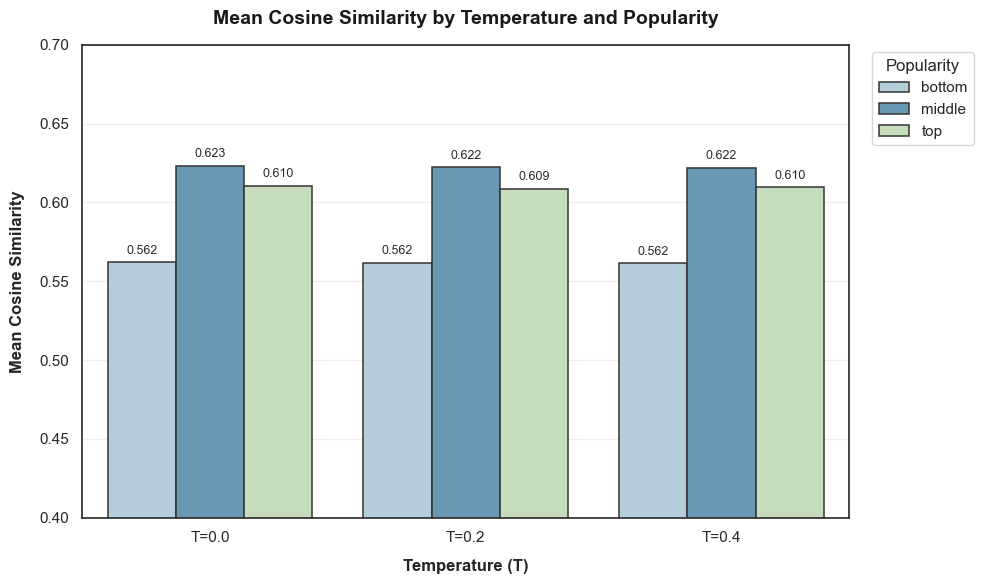

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data
df = pd.read_csv('summary_Mean_Evaluate.csv')

# 2. Set formal style parameters
sns.set_theme(style="whitegrid", rc={
    "axes.edgecolor": "0.15",
    "axes.linewidth": 1.2,
    "grid.color": "#f0f0f0"
})
plt.figure(figsize=(10, 6))

# 3. Define a formal, muted color palette (similar to image_2463e0.png)
# Muted soft blue, corporate steel blue, and a subtle sage green
formal_colors = ["#b0cfe2", "#5c9bc2", "#c4e2b8"]

# 4. Create the grouped bar chart
ax = sns.barplot(
    data=df, 
    x='Temperature', 
    y='Mean_Cosine_Similarity', 
    hue='Popularity', 
    palette=formal_colors,
    edgecolor="0.2",       # Adds a sharp, clean border to the bars
    linewidth=1.1
)

# 5. Zoom into the data range for visual clarity
plt.ylim(0.4, 0.7)

# 6. Formal styling for text and labels
plt.title('Mean Cosine Similarity by Temperature and Popularity', fontsize=14, fontweight='bold', pad=15, color='#1a1a1a')
plt.xlabel('Temperature (T)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Mean Cosine Similarity', fontsize=12, fontweight='bold', labelpad=10)

# Format the x-ticks to display exactly like your reference (e.g., T=0.2)
ax.set_xticklabels([f"T={float(label.get_text()):.1f}" for label in ax.get_xticklabels()], fontsize=11)

# 7. Clean up the legend layout
plt.legend(title='Popularity', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, facecolor='white', edgecolor='0.8')

# 8. Add values on top of bars with clean formatting
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=4, fontsize=9, color='#2c2c2c')

plt.tight_layout()
plt.show()

In [31]:
import pandas as pd

# List of temperatures to loop through
temperatures = [0, 0.2, 0.4]

for temp in temperatures:
    # Dynamically build the input filename
    input_file = f"{temp}_description_RQ2.csv"
    
    # Load the original dataset
    df = pd.read_csv(input_file)
    
    # Aggregate mean, standard deviation (std), and median over the 5 runs
    grouped = df.groupby(['Library', 'Popularity', 'Temperature'], as_index=False).agg(
        Mean_cosine=('Cosine_sim', 'mean'),
        Std_Cosine_Similarity=('Cosine_sim', 'std'),
        Median_Cosine_Similarity=('Cosine_sim', 'median')
    )
    
    # Rename metadata columns to match your exact requirements
    grouped = grouped.rename(columns={
        'Library': 'Lib_Name',
        'Popularity': 'popularity',
        'Temperature': 'Temp'
    })
    
    # Reorder the columns cleanly
    grouped = grouped[[
        'Lib_Name', 
        'popularity', 
        'Mean_cosine', 
        'Std_Cosine_Similarity', 
        'Median_Cosine_Similarity', 
        'Temp'
    ]]
    
    # Dynamically build the output filename
    output_file = f"{temp}_Similarity.csv"
    grouped.to_csv(output_file, index=False)
    
    print(f"Processed {input_file} -> Saved {output_file}")

Processed 0_description_RQ2.csv -> Saved 0_Similarity.csv
Processed 0.2_description_RQ2.csv -> Saved 0.2_Similarity.csv
Processed 0.4_description_RQ2.csv -> Saved 0.4_Similarity.csv


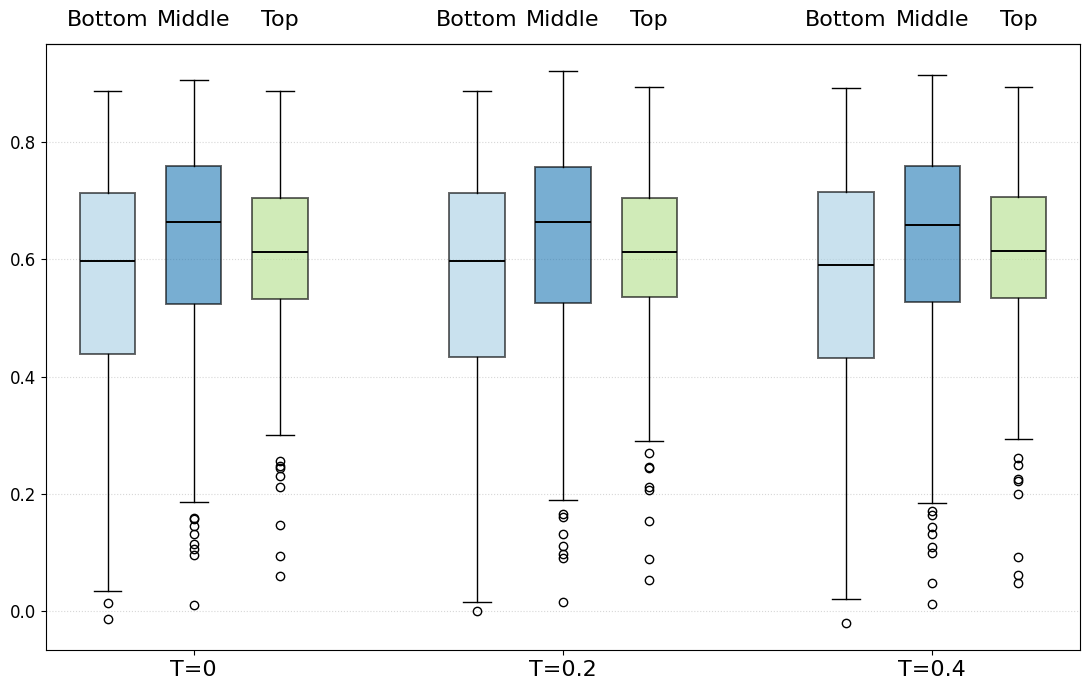

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# === Config ===
temps = [0, 0.2, 0.4]
tiers = ["Bottom", "Middle", "Top"]

csv_tmpl = "{t}_Similarity.csv"

# === Load data ===
boxes = {}

for t in temps:
    df = pd.read_csv(csv_tmpl.format(t=t))
    
    for tier in tiers:
        vals = df.loc[
            df["popularity"].str.casefold() == tier.casefold(),
            "Mean_cosine"
        ].dropna().tolist()
        
        boxes[(t, tier)] = vals

# === Plot layout ===
group_gap = 3.0
within_gap = 0.7
width = 0.45
colors = ["#a6cee3", "#1f78b4", "#b2df8a"]

fig, ax = plt.subplots(figsize=(11, 7))

# === Draw grouped boxplots (RQ2 style) ===
for tier_idx, tier in enumerate(tiers):
    pos = [i * group_gap + (tier_idx - 1) * within_gap for i in range(len(temps))]
    
    ax.boxplot(
        [boxes[(t, tier)] for t in temps],
        positions=pos,
        widths=width,
        patch_artist=True,
        boxprops=dict(facecolor=colors[tier_idx], alpha=0.6, linewidth=1.4),
        medianprops=dict(color="black", linewidth=1.4)
    )

# === X-axis: Temperature labels ===
group_centers = [i * group_gap for i in range(len(temps))]
ax.set_xticks(group_centers)
ax.set_xticklabels([f"T={t}" for t in temps], fontsize=16, fontweight='medium')

# === Top axis: Tier labels (same style as RQ2) ===
tier_positions = []
tier_labels = []

for g in range(len(temps)):
    for tier_idx, tier in enumerate(tiers):
        tier_positions.append(group_centers[g] + (tier_idx - 1) * within_gap)
        tier_labels.append(tier)

ax_top = ax.secondary_xaxis('top')
ax_top.set_xticks(tier_positions)
ax_top.set_xticklabels(tier_labels, fontsize=16, fontweight='medium')
ax_top.tick_params(axis="x", length=0, pad=10)

# === Style (match RQ2) ===
ax.tick_params(axis="y", labelsize=12)
ax.grid(True, axis="y", linestyle=":", alpha=0.5)

plt.subplots_adjust(top=0.88, bottom=0.15)
plt.tight_layout()

plt.savefig("RQ1_result_Sim.png", dpi=300, bbox_inches='tight')
plt.show()

In [15]:
import pandas as pd
from scipy.stats import kruskal

temps = [0, 0.2, 0.4]

for t in temps:
    path = f"{t}_Similarity.csv"
    df = pd.read_csv(path)

    # Extract per-tier similarity lists
    top_vals = df.loc[df["popularity"].str.lower() == "top", "Mean_cosine"]
    mid_vals = df.loc[df["popularity"].str.lower() == "middle", "Mean_cosine"]
    bot_vals = df.loc[df["popularity"].str.lower() == "bottom", "Mean_cosine"]

    # Run Kruskal–Wallis test
    stat, p = kruskal(top_vals, mid_vals, bot_vals)

    # Print summary
    print(f"\nTemperature {t}")
    print(f"Kruskal–Wallis H-statistic = {stat:.4f}, p-value = {p:.4e}")

    # Interpret result
    if p < 0.05:
        print("➡️ Significant difference between at least two tiers")
    else:
        print("➡️ No significant difference between tiers")



Temperature 0
Kruskal–Wallis H-statistic = 27.8296, p-value = 9.0549e-07
➡️ Significant difference between at least two tiers

Temperature 0.2
Kruskal–Wallis H-statistic = 26.8801, p-value = 1.4557e-06
➡️ Significant difference between at least two tiers

Temperature 0.4
Kruskal–Wallis H-statistic = 27.2696, p-value = 1.1981e-06
➡️ Significant difference between at least two tiers


Word Count Difference

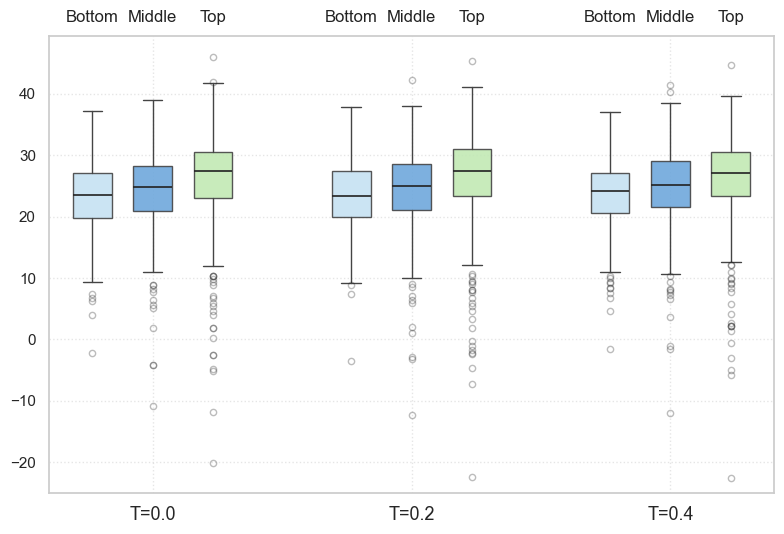

In [35]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Load and sanitize data
df = pd.read_csv("Average_Word_Count_Difference.csv")
df["Temp"] = df["Temp"].astype(float)
df["popularity"] = df["popularity"].astype(str).str.capitalize()

temps = [0.0, 0.2, 0.4]
tiers = ["Bottom", "Middle", "Top"]

# 2. Extract data arrays into a dictionary mapping (temp, tier) -> data values
boxes = {}
for t in temps:
    for tier in tiers:
        # Filter the matching rows
        sub_df = df[(df["Temp"] == t) & (df["popularity"] == tier)]
        boxes[(t, tier)] = sub_df["Mean_Word_Count_Difference"].dropna().values

# === Plot layout ===
# Tuning these values gives you the exact tight-but-distinct grouping from Image 1
group_gap = 3.0
within_gap = 0.7
width = 0.45    # Width of each box
colors = ["#C6E2F2", "#6FA8DC", "#C2E9B4"] # Your original palette from Image 2

# 2. Canvas setup - Clean proportions
fig, ax = plt.subplots(figsize=(8, 5.5))

# Pass keys directly to ax.grid without the "grid." prefix
ax.grid(True, axis="y", linestyle=":", alpha=0.5)
ax.set_axisbelow(True) # Keep gridlines behind boxes

# === Draw grouped boxplots ===
for tier_idx, tier in enumerate(tiers):
    # Calculate exact positions for this specific tier across all temperatures
    pos = [i * group_gap + (tier_idx - 1) * within_gap for i in range(len(temps))]
    
    ax.boxplot(
        [boxes[(t, tier)] for t in temps],
        positions=pos,
        widths=width,
        patch_artist=True,
        # Styles matching your exact color choices and edge definitions
        boxprops=dict(facecolor=colors[tier_idx], color="#444444", alpha=0.9, linewidth=1.0),
        medianprops=dict(color="#222222", linewidth=1.2),
        whiskerprops=dict(color="#444444", linewidth=1.0),
        capprops=dict(color="#444444", linewidth=1.0),
        flierprops=dict(markeredgecolor="#222222", markerfacecolor="none", markersize=4.5, alpha=0.3)
    )

# === X-axis (Bottom): Temperature labels ===
group_centers = [i * group_gap for i in range(len(temps))]
ax.set_xticks(group_centers)
ax.set_xticklabels([f"T={t}" for t in temps], fontsize=13)

# === X-axis (Top): Tier labels ===
tier_positions = []
tier_labels = []

for g in range(len(temps)):
    for tier_idx, tier in enumerate(tiers):
        tier_positions.append(group_centers[g] + (tier_idx - 1) * within_gap)
        tier_labels.append(tier)

ax_top = ax.secondary_xaxis('top')
ax_top.set_xticks(tier_positions)
ax_top.set_xticklabels(tier_labels, fontsize=12, color="#222222", weight="medium")
ax_top.tick_params(axis="x", length=0, pad=8)

# === Style Adjustments ===
ax.tick_params(axis="y", labelsize=11)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_ylim(bottom=-25)

# Clear spine outlines for a clean modern layout
for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_color("#cccccc")
    if ax_top.spines.get(spine):
        ax_top.spines[spine].set_visible(False)

plt.subplots_adjust(top=0.88, bottom=0.12)
plt.tight_layout()

plt.savefig("word_count_difference.png", dpi=300)
plt.show()

### Research Question 2 ###

In [1]:
import pandas as pd
from scipy.stats import kruskal

# List of files you want to analyze
files = {
    "T=0.0": "0_description_RQ2.csv",
    "T=0.2": "0.2_description_RQ2.csv",
    "T=0.4": "0.4_description_RQ2.csv"
}

print("--- Kruskal-Wallis Test Results ---")

for temp, filename in files.items():
    try:
        # Load the dataset
        df = pd.read_csv(filename)
        
        # Group Gunning_Fog_Index by Popularity tiers
        # (Assuming your tiers are labeled 'top', 'middle', 'bottom')
        top_tier = df[df['Popularity'].str.lower() == 'top']['Gunning_Fog_Index']
        middle_tier = df[df['Popularity'].str.lower() == 'middle']['Gunning_Fog_Index']
        bottom_tier = df[df['Popularity'].str.lower() == 'bottom']['Gunning_Fog_Index']
        
        # Check if we have data for all groups
        if len(top_tier) > 0 and len(middle_tier) > 0 and len(bottom_tier) > 0:
            # Perform Kruskal-Wallis test
            h_stat, p_val = kruskal(top_tier, middle_tier, bottom_tier)
            
            # Print the formatted output for your LaTeX syntax
            print(f"At {temp}: H(2) = {h_stat:.2f}, p = {p_val:.4f}")
        else:
            print(f"At {temp}: Missing data in one or more popularity tiers.")
            
    except FileNotFoundError:
        print(f"Could not find file: {filename}")
    except KeyError:
        print(f"Check your column names in {filename}. Expecting 'Popularity' and 'Gunning_Fog_Index'.")

--- Kruskal-Wallis Test Results ---
At T=0.0: H(2) = 597.90, p = 0.0000
At T=0.2: H(2) = 625.94, p = 0.0000
At T=0.4: H(2) = 591.05, p = 0.0000
